In [ ]:
try:
  # This command only in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import os
import numpy as np
import matplotlib.pyplot as plt

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [ ]:
# Get project files
!wget https://cdn.freecodecamp.org/project-data/cats-and-dogs/cats_and_dogs.zip

!unzip cats_and_dogs.zip

PATH = 'cats_and_dogs'

train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')
test_dir = os.path.join(PATH, 'test')

# Get number of files in each directory. The train and validation directories
# each have the subdirecories "dogs" and "cats".
total_train = sum([len(files) for r, d, files in os.walk(train_dir)])
total_val = sum([len(files) for r, d, files in os.walk(validation_dir)])
total_test = len(os.listdir(test_dir))

# Variables for pre-processing and training.
batch_size = 128
epochs = 15
IMG_HEIGHT = 150
IMG_WIDTH = 150

Streaming output truncated to the last 5000 lines.
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.60.jpg  
  inflating: cats_and_dogs/train/dogs/dog.858.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.858.jpg  
  inflating: cats_and_dogs/train/dogs/dog.680.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.680.jpg  
  inflating: cats_and_dogs/train/dogs/dog.694.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.694.jpg  
  inflating: cats_and_dogs/train/dogs/dog.864.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.864.jpg  
  inflating: cats_and_dogs/train/dogs/dog.870.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.870.jpg  
  inflating: cats_and_dogs/train/dogs/dog.871.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.871.jpg  
  inflating: cats_and_dogs/train/dogs/dog.865.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.865.jpg  
  inflating: cats_and_dogs/train/dogs/dog.695.jpg  
  inflating: __MACOSX/cats_and

In [ ]:
train_image_generator = ImageDataGenerator(rescale=1./255)
validation_image_generator = ImageDataGenerator(rescale=1./255)
test_image_generator = ImageDataGenerator(rescale=1./255)

train_data_gen = train_image_generator.flow_from_directory(batch_size=batch_size,
                                                     directory=train_dir,
                                                     target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                     class_mode='binary')

val_data_gen = validation_image_generator.flow_from_directory(batch_size=batch_size,
                                                     directory=validation_dir,
                                                     target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                     class_mode='binary')

test_data_gen = test_image_generator.flow_from_directory(batch_size=batch_size,
                                                     directory=test_dir,
                                                     target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                     class_mode='binary',
                                                     shuffle=False)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 0 images belonging to 0 classes.


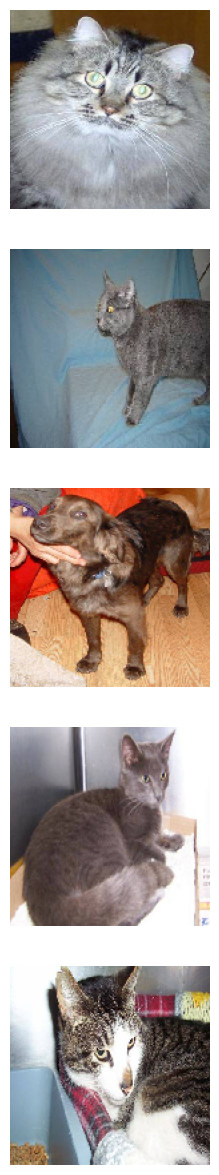

In [ ]:
# 4
def plotImages(images_arr, probabilities = False):
    fig, axes = plt.subplots(len(images_arr), 1, figsize=(5,len(images_arr) * 3))
    if probabilities is False:
      for img, ax in zip( images_arr, axes):
          ax.imshow(img)
          ax.axis('off')
    else:
      for img, probability, ax in zip( images_arr, probabilities, axes):
          ax.imshow(img)
          ax.axis('off')
          if probability > 0.5:
              ax.set_title("%.2f" % (probability*100) + "% dog")
          else:
              ax.set_title("%.2f" % ((1-probability)*100) + "% cat")
    plt.show()

sample_training_images, _ = next(train_data_gen)
plotImages(sample_training_images[:5])


In [ ]:
# 5
train_image_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

Found 2000 images belonging to 2 classes.


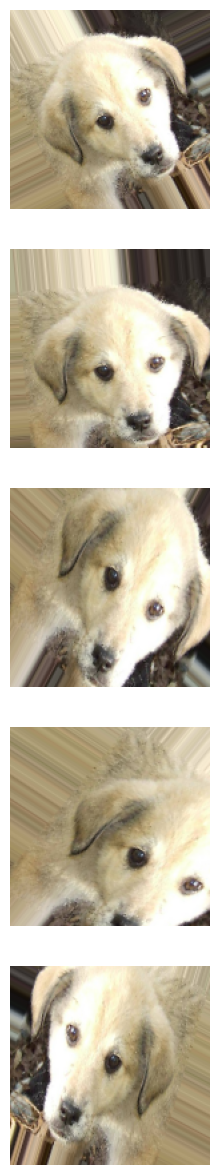

In [ ]:
# 6
train_data_gen = train_image_generator.flow_from_directory(batch_size=batch_size,
                                                     directory=train_dir,
                                                     target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                     class_mode='binary')

augmented_images = [train_data_gen[0][0][0] for i in range(5)]

plotImages(augmented_images)

In [ ]:
model = Sequential([
    Conv2D(16, 3, padding='same', activation='relu',
           input_shape=(IMG_HEIGHT, IMG_WIDTH ,3)),
    MaxPooling2D(),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])








model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,641,441 (40.59 MB)

 Trainable params: 10,641,441 (40.59 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.models import Sequential # Importing the necessary class
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D

# Define IMG_HEIGHT and IMG_WIDTH here
IMG_HEIGHT = 100
IMG_WIDTH = 100

model = Sequential([
    Conv2D(16, 3, padding='same', activation='relu',
           input_shape=(IMG_HEIGHT, IMG_WIDTH ,3)),
    MaxPooling2D(),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmented training generator
train_image_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation generator (no augmentation)
validation_image_generator = ImageDataGenerator(rescale=1./255)

# Reload dataset paths if needed
train_data_gen = train_image_generator.flow_from_directory(
    batch_size=batch_size,
    directory=train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='binary'
)

val_data_gen = validation_image_generator.flow_from_directory(
    batch_size=batch_size,
    directory=validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='binary'
)


Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [ ]:

# Retrain the model with more epochs
EPOCHS = 25

history = model.fit(
    train_data_gen,
    steps_per_epoch=len(train_data_gen),
    epochs=EPOCHS,
    validation_data=val_data_gen,
    validation_steps=len(val_data_gen)
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.5321 - loss: 0.7134 - val_accuracy: 0.5210 - val_loss: 0.6891
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.5333 - loss: 0.6906 - val_accuracy: 0.6370 - val_loss: 0.6792
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.5927 - loss: 0.6799 - val_accuracy: 0.5390 - val_loss: 0.6874
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.5903 - loss: 0.6641 - val_accuracy: 0.6310 - val_loss: 0.6234
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.6650 - loss: 0.6282 - val_accuracy: 0.6240 - val_loss: 0.6211
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.6255 - loss: 0.6418 - val_accuracy: 0.7080 - val_loss: 0.5865
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.6573 - loss: 0.6197 - val_accuracy: 0.7150 - val_loss: 0.5617
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.7113 - loss: 0.5741 - val_accuracy: 0.6950 - val_loss:

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.7804 - loss: 0.4682 - val_accuracy: 0.7400 - val_loss: 0.5094
Epoch 2/15
 1/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7266 - loss: 0.4738

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 256ms/step - accuracy: 0.7266 - loss: 0.4738 - val_accuracy: 0.7277 - val_loss: 0.5347
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.7892 - loss: 0.4590 - val_accuracy: 0.7634 - val_loss: 0.4955
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 349ms/step - accuracy: 0.7891 - loss: 0.4475 - val_accuracy: 0.7612 - val_loss: 0.5046
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.7841 - loss: 0.4529 - val_accuracy: 0.7433 - val_loss: 0.4968
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 643ms/step - accuracy: 0.7500 - loss: 0.4915 - val_accuracy: 0.7455 - val_loss: 0.5005
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.7983 - loss: 0.4330 - val_accuracy: 0.7779 - val_loss: 0.4727
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 343ms/step - accuracy: 0.8359 - loss: 0.4316 - val_accuracy: 0.7679 - val_loss: 0.4926
Epoch 9/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.7968 - loss: 0.4378 - val_accuracy: 0.7723 - val_loss: 0

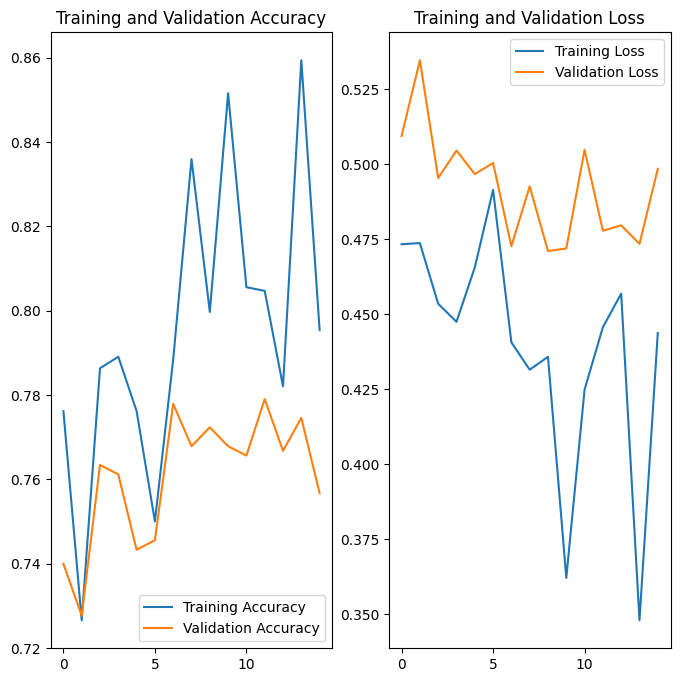

In [ ]:
# Fit the model
history = model.fit(
    train_data_gen,
    steps_per_epoch=total_train // batch_size,
    epochs=epochs,
    validation_data=val_data_gen,
    validation_steps=total_val // batch_size
)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
print(test_df.head())
print(f"Total test images found: {len(test_df)}")


                             filename
0  /content/cats_and_dogs/test/21.jpg
1  /content/cats_and_dogs/test/26.jpg
2  /content/cats_and_dogs/test/30.jpg
3  /content/cats_and_dogs/test/23.jpg
4  /content/cats_and_dogs/test/37.jpg
Total test images found: 50


In [ ]:
from PIL import Image

bad_files = 0
for i, path in enumerate(test_df['filename']):
    try:
        img = Image.open(path)
        img.verify()  # Validate it without opening
    except Exception as e:
        print(f"❌ Problem with file {path}: {e}")
        bad_files += 1

print(f"\n✅ Finished checking. Bad files: {bad_files}")



✅ Finished checking. Bad files: 0


In [ ]:
test_data_gen = test_image_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='filename',
    y_col=None,
    class_mode=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=1,
    shuffle=False
)


Found 50 validated image filenames.


In [ ]:
print(f"Samples found in generator: {test_data_gen.samples}")


Samples found in generator: 50


In [ ]:
predictions = model.predict(test_data_gen)
probabilities = [1 if p >= 0.5 else 0 for p in predictions.flatten()]


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


In [ ]:
predictions = model.predict(test_data_gen)

# Convert model output to binary 0 or 1 (0 = cat, 1 = dog)
probabilities = [1 if p >= 0.5 else 0 for p in predictions.flatten()]


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


In [ ]:
answers = [1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
           1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
           1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
           1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
           0, 0, 0, 0, 0, 0]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training data generator with augmentation
train_image_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation data generator (no augmentation)
validation_image_generator = ImageDataGenerator(rescale=1./255)

# Regenerate data loaders with new image size (IMG_HEIGHT and IMG_WIDTH assumed set to 150)
train_data_gen = train_image_generator.flow_from_directory(
    batch_size=batch_size,
    directory=train_dir,
    shuffle


SyntaxError: incomplete input (<ipython-input-60-b0a61801f914>, line 21)